# Importar librerías

In [1]:
import sys
from pathlib import Path

# encontrar raíz del proyecto (carpeta que contiene "src")
root = Path().resolve()
while not (root / "src").exists():
    root = root.parent

sys.path.append(str(root))

In [2]:
import pandas as pd
from src.data.load_data import cargar_csv
from src.features.feature_engineering import crear_variables, grafico_matriz_correlacion

# Cargar base de datos

In [3]:
ruta_archivo = '../databases/processed/base_limpia_procesada.csv'

In [4]:
archivo = cargar_csv(ruta_archivo)
archivo.head()

,customer_id,churn_label,signup_date,last_purchase_date,monthly_spend,total_shipments,signup_date_year,signup_date_month,last_purchase_date_year,last_purchase_date_month,customer_tenure_days,days_since_last_purchase,signup_month,purchase_month
0,C001,0,2023-01-15,2025-12-05,450.5,12,2023,1,2025.0,12.0,1146,139.125,2023-01-01,2025-12-01
1,C002,0,2023-02-20,2025-05-10,1200.0,45,2023,2,2025.0,5.0,1110,300.000,2023-02-01,2025-05-01
2,C003,1,2023-03-05,2025-03-25,3435.0,8,2023,3,2025.0,3.0,1097,346.000,2023-03-01,2025-03-01
3,C004,0,2023-04-12,2025-06-01,890.2,22,2023,4,2025.0,6.0,1059,278.000,2023-04-01,2025-06-01
4,C005,1,2023-05-30,2024-12-20,310.0,5,2023,5,2024.0,12.0,1011,441.000,2023-05-01,2024-12-01


In [5]:
archivo['signup_date'] = pd.to_datetime(archivo['signup_date'], format='%Y-%m-%d')
archivo['last_purchase_date'] = pd.to_datetime(archivo['last_purchase_date'], format='%Y-%m-%d')
archivo['signup_month'] = pd.to_datetime(archivo['signup_month'], format='%Y-%m-%d')
archivo['purchase_month'] = pd.to_datetime(archivo['purchase_month'], format='%Y-%m-%d')

# Feature engineering

In [6]:
archivo['last_purchase_date'] = archivo['last_purchase_date'].fillna(archivo['signup_date'])
# se asume que la última compra fui el dia de ingreso

In [7]:
archivo = crear_variables(archivo)

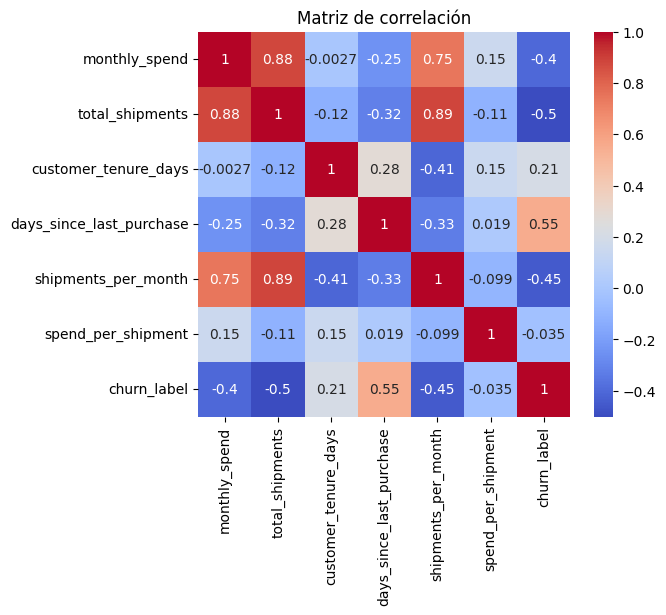

In [8]:
grafico_matriz_correlacion(archivo, ['monthly_spend', 'total_shipments', 'customer_tenure_days', 'days_since_last_purchase',
             'shipments_per_month', 'spend_per_shipment','churn_label'])

In [9]:
archivo['churn_label'].value_counts(True).to_dict()

{0: 0.7522935779816514, 1: 0.24770642201834864}

# Seleccionar variables finales y exportar

In [10]:
archivo = archivo[['customer_id','churn_label', 'monthly_spend', 'total_shipments', 'customer_tenure_days', 'days_since_last_purchase',
                   'shipments_per_month', 'spend_per_shipment']]

In [11]:
archivo.to_csv('../databases/processed/base_feature_engineering.csv', sep=',', index=False)